# USA Housing

Năm cột số dùng để đoán:

- Avg. Area Income là thu nhập trung bình của khu vực
- Avg. Area House Age là tuổi nhà trung bình
- Avg. Area Number of Rooms là số phòng trung bình
- Avg. Area Number of Bedrooms là số phòng ngủ trung bình
- Area Population là dân số khu vực

Address là địa chỉ chữ. Cột này không đưa vào mô hình.


## 1. Đọc dữ liệu


In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("../data/USA_Housing.csv")
df.head()


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,USNS Raymond\nFPO AE 09386


## 2. Xem tổng quan

describe cho trung bình, giá trị nhỏ nhất và lớn nhất của các cột số. Giá trung bình khoảng 1,232,073.

columns in đủ 7 tên cột, kể cả Address.


In [29]:
df.describe(include='all') #tóm tắt toàn bộ thông tin thống kê

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03,5000
unique,NaN,NaN,NaN,NaN,NaN,NaN,5000
top,NaN,NaN,NaN,NaN,NaN,NaN,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
freq,NaN,NaN,NaN,NaN,NaN,NaN,1
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06,NaN
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05,NaN
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04,NaN
25%,61480.562390,5.322283,6.299250,3.140000,29403.928700,9.975771e+05,NaN
50%,68804.286405,5.970429,7.002902,4.050000,36199.406690,1.232669e+06,NaN
75%,75783.338665,6.650808,7.665871,4.490000,42861.290770,1.471210e+06,NaN


In [30]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='str')

In [31]:
# df = ?
df=df.drop(columns=['Address']) #xóa cột 
df.head()


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05


## 4. Thu nhập khu vực và giá

Biểu đồ này đặt Avg. Area Income trên trục ngang và Price trên trục dọc. Khu có thu nhập cao hơn thường có giá nhà cao hơn. Đám điểm đi theo một hướng, chưa thành một đường thẳng duy nhất vì giá còn phụ thuộc tuổi nhà, số phòng và dân số.


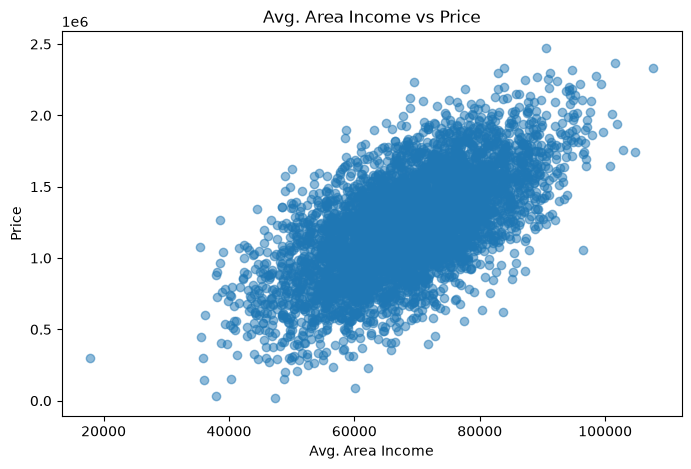

In [32]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Avg. Area Income'], df['Price'], alpha=0.5)

plt.xlabel('Avg. Area Income')
plt.ylabel('Price')
plt.title('Avg. Area Income vs Price')
plt.show()

## 5. Tách feature, label, rồi chia tập



In [33]:
df.shape

(5000, 6)

In [34]:
# Feature: 
X = df.drop(columns=['Price']) #5 cột dùng để dự đoán

# Label: 
y = df['Price'] #giá nhà cần dự đoán

# Chia dữ liệu: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (4000, 5)
X_test: (1000, 5)


## 6. Training

$$\hat{y} = w_1 x_1 + w_2 x_2 + w_3 x_3 + w_4 x_4 + w_5 x_5 + b$$

Năm weight nằm trong coef_. b là intercept_.


In [35]:
model = LinearRegression() #Khởi tạo một đối tượng mô hình Hồi quy tuyến tính chưa có dữ liệu
model.fit(X_train, y_train) #Huấn luyện mô hình bằng dữ liệu thực tế

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 21.65,164666.48,119624.01, 2440.38, 15.27]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Avg. Area Income','Avg. Area House Age','Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms','Area Population']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.635e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [36]:
y_pred = model.predict(X_test) #Cho mô hình dự đoán kết quả tập X_test
mse = mean_squared_error(y_test, y_pred) 
r2 = r2_score(y_test, y_pred) #Độ chính xác của mô hình từ 0 đến 1 (càng gần 1 càng tốt)
rmse = np.sqrt(mse) #Căn bậc hai của MSE (chênh lệch càng nhỏ càng tốt)

print("MSE =", f"{mse:,.0f}")
print("RMSE =", f"{rmse:,.0f}")
print("R2 =", round(r2, 3))

MSE = 10,089,009,299
RMSE = 100,444
R2 = 0.918


## 8. Một căn trong tập kiểm tra

Căn đầu tiên của tập kiểm tra không nằm trong tập học. In giá thật cạnh giá đoán. Hai số có dấu phẩy để dễ đọc.

Nếu giá đoán gần giá thật và khoảng lệch nhỏ hơn RMSE, căn đó nằm trong mức sai số trung bình của mô hình.


In [ ]:
can = X_test.iloc[[0]] #bốc đúng 1 dòng đầu tiên ra ngoài nhưng vẫn giữ nguyên định dạng bảng
gia_that = y_test.iloc[0] #Lấy giá bán thực tế của căn nhà đó
gia_doan = model.predict(can)[0] #Đưa thông tin căn nhà vào mô hình để dự đoán giá

# print(can)
print("Real price =", f"{gia_that:,.0f}")
print("Predicted price =", f"{gia_doan:,.0f}")
print("Difference =", f"{abs(gia_that - gia_doan):,.0f}")

Real price = 1,339,096
Predicted price = 1,308,588
Difference = 30,508


## 9. Save model

joblib.dump ghi weight và bias ra USA_Housing.pkl. joblib.load đọc lại khi cần đoán, không cần fit lại.

Khu thử dùng năm số tròn để dễ nhìn: thu nhập 70,000, tuổi nhà 6, 7 phòng, 4 phòng ngủ, dân số 40,000.


In [38]:
import joblib

joblib.dump(model, "USA_Housing.pkl") #Đóng gói đối tượng model và lưu thành tệp tên là USA_Housing.pkl
print("Đã lưu model")

Đã lưu model


In [39]:
new_house = pd.DataFrame({
    'Avg. Area Income': [70000],
    'Avg. Area House Age': [6],
    'Avg. Area Number of Rooms': [7],
    'Avg. Area Number of Bedrooms': [4],
    'Area Population': [40000]
}) #tạo dữ liệu

new_house = new_house[X.columns] #xếp thứ tự 
gia_du_doan = model.predict(new_house)[0] #đưa thông số căn nhà mới vào mô hình để dự đoán giá

print("Predicted Price =", f"{gia_du_doan:,.0f}") #có dấu phẩy hàng nghìn

Predicted Price = 1,326,523
